# Capstone Project

## EDA

In [2]:
#Importing libraries
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [3]:
#reading in data file
HR = 'Employee.csv'
HR_df = pd.read_csv(HR)
HR_df.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6


In [4]:
HR_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   EmployeeID               1470 non-null   object
 1   FirstName                1470 non-null   object
 2   LastName                 1470 non-null   object
 3   Gender                   1470 non-null   object
 4   Age                      1470 non-null   int64 
 5   BusinessTravel           1470 non-null   object
 6   Department               1470 non-null   object
 7   DistanceFromHome (KM)    1470 non-null   int64 
 8   State                    1470 non-null   object
 9   Ethnicity                1470 non-null   object
 10  Education                1470 non-null   int64 
 11  EducationField           1470 non-null   object
 12  JobRole                  1470 non-null   object
 13  MaritalStatus            1470 non-null   object
 14  Salary                   1470 non-null  

In [5]:
#reading in data file
Perf = 'PerformanceRating.csv'
Perf_df = pd.read_csv(Perf)
Perf_df.head()

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,1/2/2013,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,1/3/2013,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,1/3/2013,3,4,5,3,2,3,5,4
3,PR04,0678-748A,1/4/2013,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,1/4/2013,5,2,3,1,0,4,4,3


In [6]:
#Ensure the date column is in datetime format
Perf_df['ReviewDate'] = pd.to_datetime(Perf_df['ReviewDate'])

Perf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   PerformanceID                    6709 non-null   object        
 1   EmployeeID                       6709 non-null   object        
 2   ReviewDate                       6709 non-null   datetime64[ns]
 3   EnvironmentSatisfaction          6709 non-null   int64         
 4   JobSatisfaction                  6709 non-null   int64         
 5   RelationshipSatisfaction         6709 non-null   int64         
 6   TrainingOpportunitiesWithinYear  6709 non-null   int64         
 7   TrainingOpportunitiesTaken       6709 non-null   int64         
 8   WorkLifeBalance                  6709 non-null   int64         
 9   SelfRating                       6709 non-null   int64         
 10  ManagerRating                    6709 non-null   int64      

In [7]:
#Sort by date ascending, then keep the last entry for each item
Per_latest_df = Perf_df.sort_values('ReviewDate').reset_index().drop_duplicates(subset=['EmployeeID'], keep='last')
Per_latest_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1280 entries, 107 to 6708
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   index                            1280 non-null   int64         
 1   PerformanceID                    1280 non-null   object        
 2   EmployeeID                       1280 non-null   object        
 3   ReviewDate                       1280 non-null   datetime64[ns]
 4   EnvironmentSatisfaction          1280 non-null   int64         
 5   JobSatisfaction                  1280 non-null   int64         
 6   RelationshipSatisfaction         1280 non-null   int64         
 7   TrainingOpportunitiesWithinYear  1280 non-null   int64         
 8   TrainingOpportunitiesTaken       1280 non-null   int64         
 9   WorkLifeBalance                  1280 non-null   int64         
 10  SelfRating                       1280 non-null   int64         

In [8]:
Per_latest_df.head()

,index,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
107,132,PR111,EE12-1C73,2013-04-23,3,4,5,3,0,4,3,3
131,365,PR132,AB61-2A7E,2013-05-09,4,2,3,3,1,5,4,3
221,1364,PR222,1FE3-22BF,2014-02-26,5,2,5,3,2,5,3,3
256,1752,PR257,0FC3-2572,2014-03-21,3,2,4,1,2,4,4,4
264,1841,PR265,E9AB-3F99,2014-03-26,5,3,4,1,0,3,4,3


In [9]:
merged_df = pd.merge(Per_latest_df, HR_df, on='EmployeeID', how='inner')
pd.set_option('display.max_columns', None)
merged_df.sample(5)

,index,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,Education,EducationField,JobRole,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
247,5202,PR5678,041A-31B0,2022-01-28,4,2,4,2,0,5,3,2,Gerri,Fullerlove,Female,34,Some Travel,Technology,41,NY,Black or African American,3,Computer Science,Software Engineer,Married,50386,1,No,2012-05-20,No,10,8,9,10
897,5922,PR6326,2EF6-8D96,2022-08-10,3,2,3,3,2,5,3,3,Lelia,Giles,Female,24,Some Travel,Technology,12,CA,White,4,Information Systems,Software Engineer,Married,22965,3,No,2018-06-12,No,4,4,4,4
69,2657,PR3385,4C06-7031,2019-10-02,3,4,4,1,0,4,3,2,Jaine,Pashan,Female,43,Some Travel,Technology,35,CA,White,5,Computer Science,Engineering Manager,Single,286660,0,No,2021-04-26,No,1,0,0,1
276,5229,PR5701,F3CD-9B5B,2022-02-03,3,4,3,1,1,3,5,4,Timothee,MacFadyen,Male,29,Some Travel,Sales,12,IL,Asian or Asian American,2,Marketing,Sales Representative,Married,97794,0,No,2013-05-30,Yes,2,0,1,0
395,5366,PR5825,4A0E-9958,2022-03-10,4,5,5,2,1,3,5,5,Axel,Aicheson,Male,26,Some Travel,Technology,6,CA,Black or African American,4,Information Systems,Machine Learning Engineer,Married,89771,2,Yes,2016-10-04,Yes,1,0,0,0


In [11]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   index                            1280 non-null   int64         
 1   PerformanceID                    1280 non-null   object        
 2   EmployeeID                       1280 non-null   object        
 3   ReviewDate                       1280 non-null   datetime64[ns]
 4   EnvironmentSatisfaction          1280 non-null   int64         
 5   JobSatisfaction                  1280 non-null   int64         
 6   RelationshipSatisfaction         1280 non-null   int64         
 7   TrainingOpportunitiesWithinYear  1280 non-null   int64         
 8   TrainingOpportunitiesTaken       1280 non-null   int64         
 9   WorkLifeBalance                  1280 non-null   int64         
 10  SelfRating                       1280 non-null   int64      

In [10]:
#Converting Attrition values from yes/no to 1/0
merged_df['Attrition'] = merged_df['Attrition'].map({'Yes': 1, 'No': 0})
merged_df['Attrition'].value_counts()

Attrition
0    1043
1     237
Name: count, dtype: int64

In [11]:
Total_att = 237/1280 * 100
print(f'Total Attrition: {Total_att:.2f}%')

Total Attrition: 18.52%


In [12]:
#Group by department to find total employees and departures
dept_att = merged_df.groupby('Department').agg(
    Total_Employees=('EmployeeID', 'count'),
    Attrition=('Attrition','sum')
).reset_index()

# Calculate Attrition Rate per category
dept_att['Attrition_Rate(%)'] = (dept_att['Attrition'] / dept_att['Total_Employees']) * 100

dept_att

,Department,Total_Employees,Attrition,Attrition_Rate(%)
0,Human Resources,53,12,22.641509
1,Sales,384,92,23.958333
2,Technology,843,133,15.776987


In [16]:
#Creating dummy variables for category columns
merged_df_encoded = pd.get_dummies(merged_df, columns=['Gender','BusinessTravel','Department','State','Ethnicity',
                                               'EducationField','JobRole','MaritalStatus','OverTime'],dtype=int)
merged_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 72 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   index                                       1280 non-null   int64         
 1   PerformanceID                               1280 non-null   object        
 2   EmployeeID                                  1280 non-null   object        
 3   ReviewDate                                  1280 non-null   datetime64[ns]
 4   EnvironmentSatisfaction                     1280 non-null   int64         
 5   JobSatisfaction                             1280 non-null   int64         
 6   RelationshipSatisfaction                    1280 non-null   int64         
 7   TrainingOpportunitiesWithinYear             1280 non-null   int64         
 8   TrainingOpportunitiesTaken                  1280 non-null   int64         
 9   WorkLife

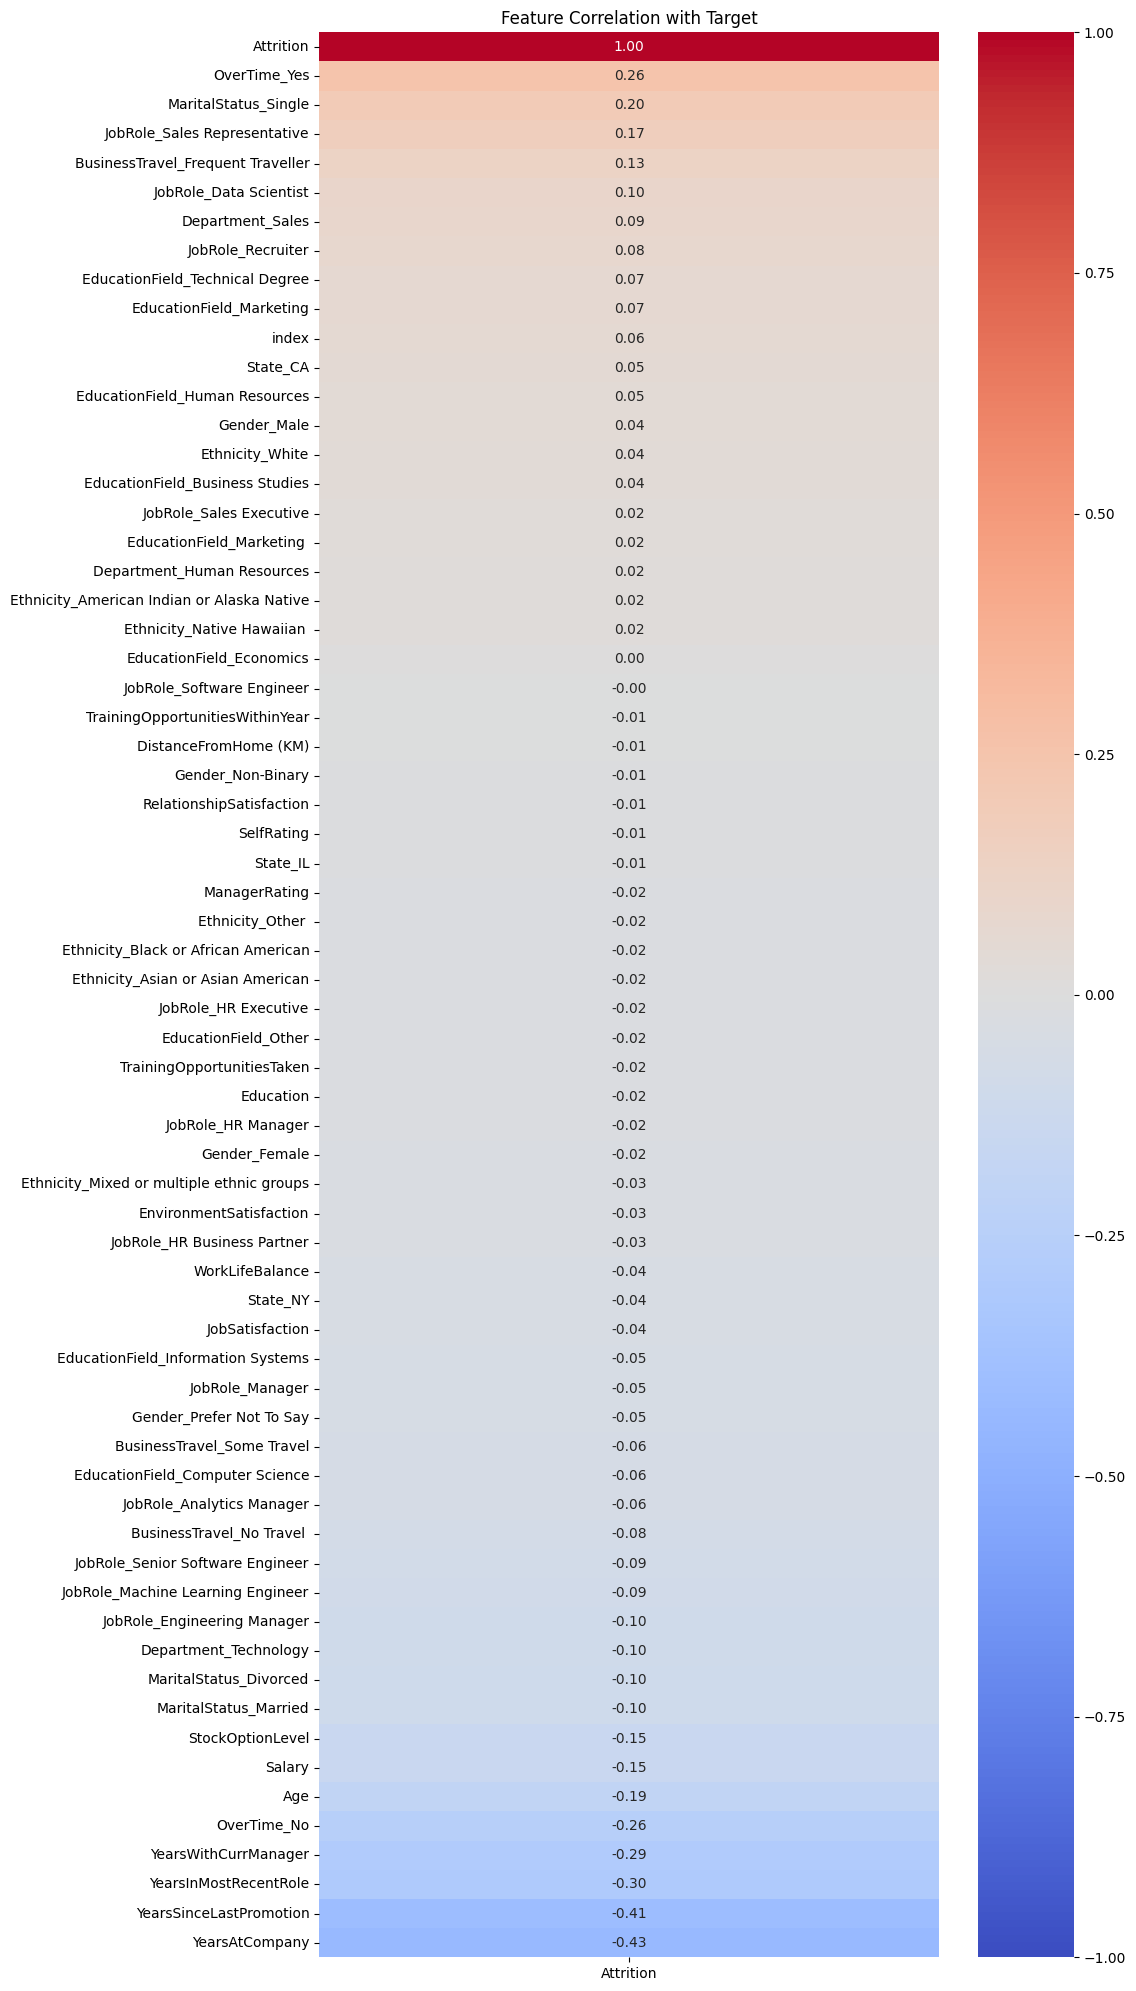

In [50]:
#Correlations table of encoded variables with Target Variable(Attrition)

target_corr = merged_df_encoded.corr(numeric_only=True)[['Attrition']].sort_values(
    by='Attrition', ascending=False
)

# 2. Plot the single-column heatmap
plt.figure(figsize=(10, 25))
sns.heatmap(target_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")

plt.title("Feature Correlation with Target")
plt.show()

In [18]:
pct_df_ot = (
    merged_df.groupby("OverTime")["Attrition"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

pct_df_ot

Attrition,0,1
OverTime,,
No,87.885463,12.114537
Yes,65.860215,34.139785


In [19]:
pct_df_ms = (
    merged_df.groupby("MaritalStatus")["Attrition"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

pct_df_ms

Attrition,0,1
MaritalStatus,,
Divorced,89.090909,10.909091
Married,86.017699,13.982301
Single,70.909091,29.090909


In [20]:
pct_df_jr = (
    merged_df.groupby("JobRole")["Attrition"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

pct_df_jr

Attrition,0,1
JobRole,,
Analytics Manager,93.617021,6.382979
Data Scientist,73.504274,26.495726
Engineering Manager,97.142857,2.857143
HR Business Partner,100.000000,NaN
HR Executive,87.500000,12.500000
HR Manager,100.000000,NaN
Machine Learning Engineer,91.803279,8.196721
Manager,93.750000,6.250000
Recruiter,57.142857,42.857143


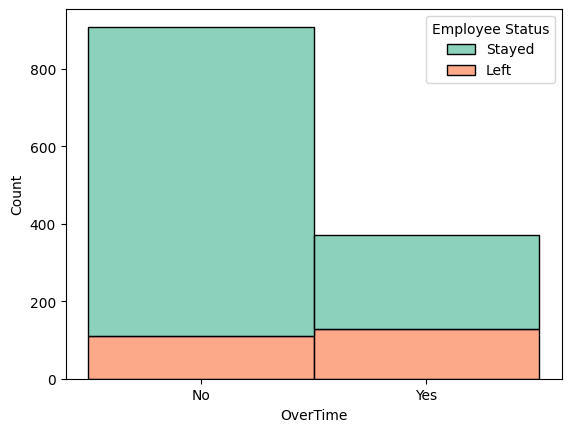

In [31]:
#Histogram of Attrition by Overtime
hp2 = sns.histplot(
    data=merged_df, 
    x='OverTime', 
    hue='Attrition',        # Split data by Attrition
    multiple='stack',  # Stack the categories               
    palette='Set2'    # Aesthetic color scheme
)


# Move, title, and rename the legend labels
sns.move_legend(
    hp2, 
    loc="upper right", 
    title="Employee Status", 
    labels=["Stayed", "Left"]
)

plt.show()


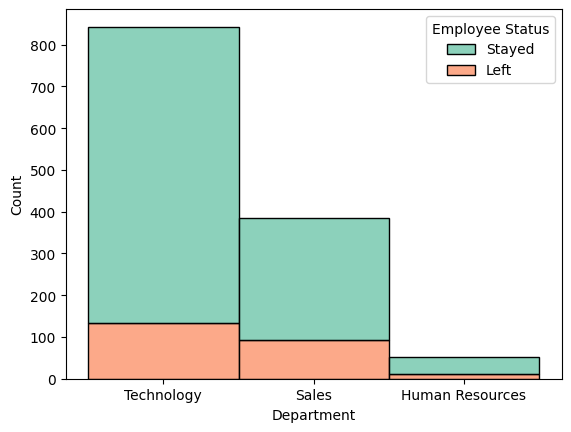

In [30]:
#Histogram of Attrition by Department
hp1 = sns.histplot(
    data=merged_df, 
    x='Department', 
    hue='Attrition',        # Split data by Attrition
    multiple='stack',  # Stack the categories               
    palette='Set2'    # Aesthetic color scheme
)


# Move, title, and rename the legend labels
sns.move_legend(
    hp1, 
    loc="upper right", 
    title="Employee Status", 
    labels=["Stayed", "Left"]
)

plt.show()

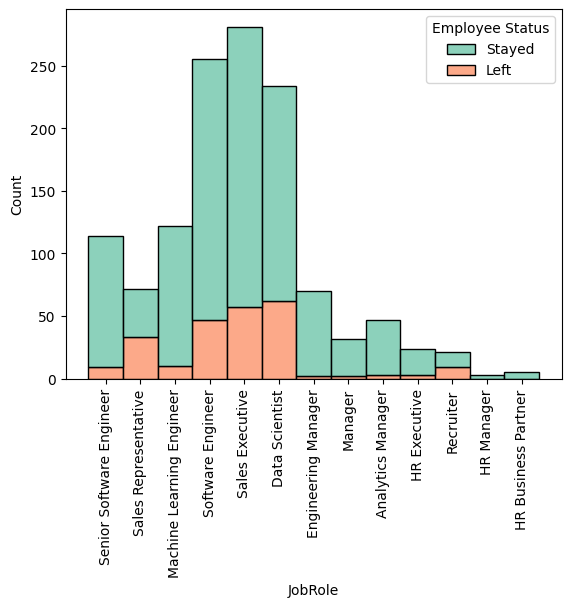

In [27]:
# Histogram of Attrition by Job Role
plt.figure
hp4 = sns.histplot(
    data=merged_df, 
    x='JobRole', 
    hue='Attrition',        
    multiple='stack',         
    binwidth=3,        
    palette='Set2'     
)

# Rotate the x-axis labels vertically
plt.xticks(rotation='vertical')

# Move, title, and rename the legend labels
sns.move_legend(
    hp4, 
    loc="upper right", 
    title="Employee Status", 
    labels=["Stayed", "Left"]
)

plt.show()

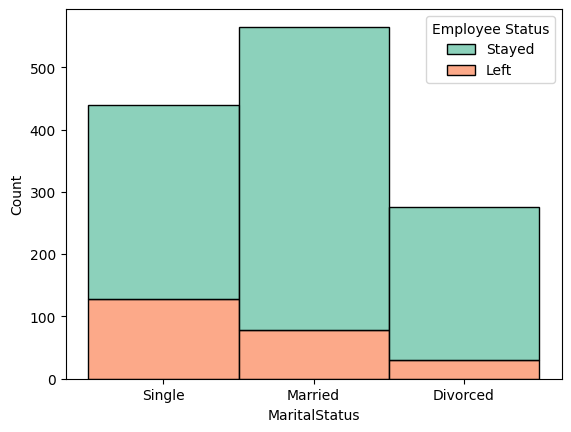

In [28]:
#Histogram of Attrition by MarriageStatus
plt.figure
hp3=sns.histplot(
    data=merged_df, 
    x='MaritalStatus', 
    hue='Attrition',        # Split data by Attrition
    multiple='stack',  # Stack the categories        
    binwidth=3,        # Explicit width per bin
    palette='Set2'     # Aesthetic color scheme
)

# Move, title, and rename the legend labels
sns.move_legend(
    hp3, 
    loc="upper right", 
    title="Employee Status", 
    labels=["Stayed", "Left"]
)

plt.show()

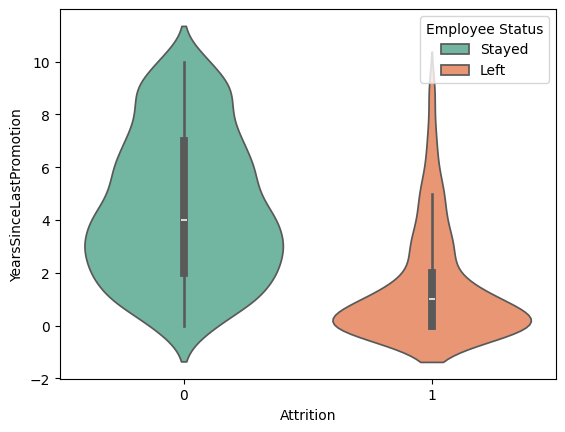

In [32]:
#Voilin Plot of Years Since Last Promotion by Attrition
vp2 = sns.violinplot(data=merged_df, x='Attrition', 
               y='YearsSinceLastPromotion', 
               hue='Attrition',
               inner='box',
               palette='Set2')

# Move, title, and rename the legend labels
sns.move_legend(
    vp2, 
    loc="upper right", 
    title="Employee Status", 
    labels=["Stayed", "Left"]
)
plt.show()

In [62]:
merged_df['YearsAtCompany'].value_counts()

YearsAtCompany
3     148
4     129
10    128
2     124
7     121
8     119
9     118
1     117
5     115
6     101
0      60
Name: count, dtype: int64

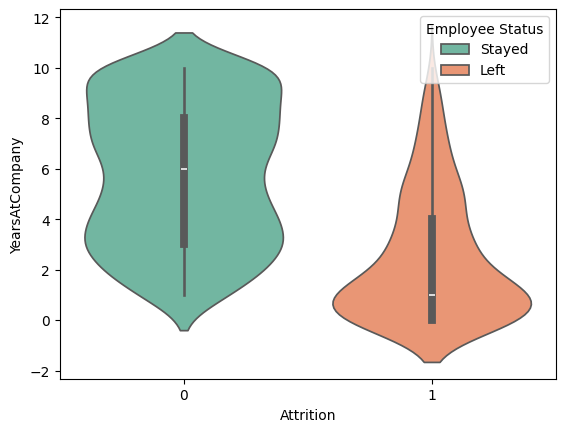

In [33]:
#Voilin Plot of Years at Company by Attrition
vp1 = sns.violinplot(data=merged_df, x='Attrition', 
               y='YearsAtCompany', 
               hue='Attrition',
               inner='box',
               palette='Set2')

# Move, title, and rename the legend labels
sns.move_legend(
    vp1, 
    loc="upper right", 
    title="Employee Status", 
    labels=["Stayed", "Left"]
)
plt.show()

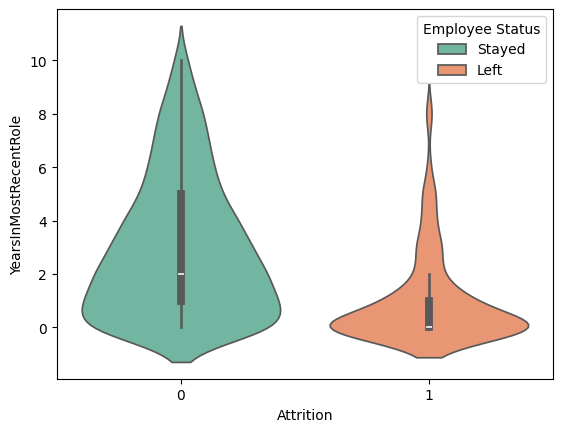

In [34]:
#Voilin Plot of Years Since Last Promotion by Attrition
vp3 = sns.violinplot(data=merged_df, x='Attrition', 
               y='YearsInMostRecentRole', 
               hue='Attrition',
               inner='box',
               palette='Set2')

# Move, title, and rename the legend labels
sns.move_legend(
    vp3, 
    loc="upper right", 
    title="Employee Status", 
    labels=["Stayed", "Left"]
)
plt.show()

## Creating cleaning function for data pipeline

In [43]:
def clean_df(df, yes_no_cols, date_cols, cols_to_drop=None):
    
    """
    Cleans data file to be used for machine learning by mapping yes/no to 1 and 0, 
    creating dummy variables, and converting time to datetime.
    """
    
    # Create a copy of the dataframe
    cleaned_df = df.copy()

    # Strip whitespace from every string cell in the entire DataFrame
    # Safely ignores integers, floats, and NaNs
    cleaned_df = cleaned_df.map(lambda x: x.strip() if isinstance(x, str) else x)
    
    # Remove unwanted columns
    if cols_to_drop:
        cleaned_df = cleaned_df.drop(columns=cols_to_drop, errors='ignore')
    
    # Convert Yes and No columns to 1 and 0
    if yes_no_cols:
        # Standardize strings to lowercase and strip whitespaces
        for col in yes_no_cols:
            cleaned_df[col] = cleaned_df[col].astype(str).str.lower().str.strip()
            # Map values (unknown/other values will become NaN)
            cleaned_df[col] = cleaned_df[col].replace({'yes': 1, 'y': 1, 'no': 0, 'n': 0}).astype(int)
        
    return cleaned_df

In [47]:
yes_no = ['StockOptionLevel','Attrition','OverTime']
dates = ['HireDate']
drop_list = ['EmployeeID','FirstName','LastName','PerformanceID','ReviewDate','index']

merged_cleaned = clean_df(
    df=merged_df, 
    yes_no_cols=yes_no,  
    date_cols=dates, 
    cols_to_drop=drop_list
)

merged_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1280 entries, 0 to 1279
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   EnvironmentSatisfaction          1280 non-null   int64 
 1   JobSatisfaction                  1280 non-null   int64 
 2   RelationshipSatisfaction         1280 non-null   int64 
 3   TrainingOpportunitiesWithinYear  1280 non-null   int64 
 4   TrainingOpportunitiesTaken       1280 non-null   int64 
 5   WorkLifeBalance                  1280 non-null   int64 
 6   SelfRating                       1280 non-null   int64 
 7   ManagerRating                    1280 non-null   int64 
 8   Gender                           1280 non-null   object
 9   Age                              1280 non-null   int64 
 10  BusinessTravel                   1280 non-null   object
 11  Department                       1280 non-null   object
 12  DistanceFromHome (KM)            1

/var/folders/p4/vxx4n3kn4q1grbl878lw90k80000gp/T/ipykernel_43181/3781059627.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_df[col] = cleaned_df[col].replace({'yes': 1, 'y': 1, 'no': 0, 'n': 0}).astype(int)


## Creating data pipeline to compare ML Algorithms

In [40]:
#Importing libraries for ML Algorithms
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler

In [41]:
#Defining Features(X) and Target variables(y)

X = merged_cleaned.drop(columns=['Attrition','HireDate'])
y = merged_cleaned['Attrition']

#Split data into train and test data set, 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

#Identify feature data types
num_feat = ['Age','DistanceFromHome (KM)',
            'Education','Salary','OverTime',
            'YearsAtCompany','YearsInMostRecentRole',
            'YearsSinceLastPromotion','YearsWithCurrManager',
            'StockOptionLevel']

cat_feat = ['Gender','BusinessTravel','Department','State',
            'Ethnicity','EducationField','JobRole','MaritalStatus']

#Create Preprocessing Sub-Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Handle missing numeric entries
    ('scaler', StandardScaler()) # Scales features to mean=0, variance=1 for stable model convergence
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Fill missing categories
    ('encoder', OneHotEncoder(handle_unknown='ignore'))   # Convert to numerical dummy variables
])

#Bundle Preprocessors Using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_feat),
        ('cat', categorical_transformer, cat_feat)
    ]
)

#Define the CART (Decision Tree) classifier
cart = DecisionTreeClassifier(random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(max_iter=2000, random_state=42),
    'AdaBoost': AdaBoostClassifier (n_estimators = 70, random_state = 42),
    'KNN': KNeighborsClassifier(n_neighbors = 1),
    'GNB': GaussianNB(),
    'GBC': GradientBoostingClassifier(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=42),
    'Bagging': BaggingClassifier(estimator = cart, n_estimators = 100, random_state = 42)
}

#Initialize, Train, and Evaluate Models in a Loop
results = {}

for model_name, model_object in models.items():
    # Construct the final workflow pipeline dynamically
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_object)
    ])
    
    # Train the pipeline (fits transformers on train data only, then trains model)
    full_pipeline.fit(X_train, y_train)
    
    # Predict on unseen test data
    y_pred = full_pipeline.predict(X_test)
    
 # Evaluate performance
    results[model_name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='binary', pos_label=1),
        'Recall': recall_score(y_test, y_pred, average='binary', pos_label=1),      
        'F1-Score': f1_score(y_test, y_pred, average='binary', pos_label=1)         
    }

#Display Performance Comparison
df_results = pd.DataFrame(results).T
df_results

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.898438,0.823529,0.583333,0.682927
Random Forest,0.894531,0.956522,0.458333,0.619718
Support Vector Machine,0.898438,0.866667,0.541667,0.666667
AdaBoost,0.890625,0.833333,0.520833,0.641026
KNN,0.839844,0.577778,0.541667,0.559140
GNB,0.335938,0.220183,1.000000,0.360902
GBC,0.890625,0.833333,0.520833,0.641026
Bagging,0.898438,0.923077,0.500000,0.648649


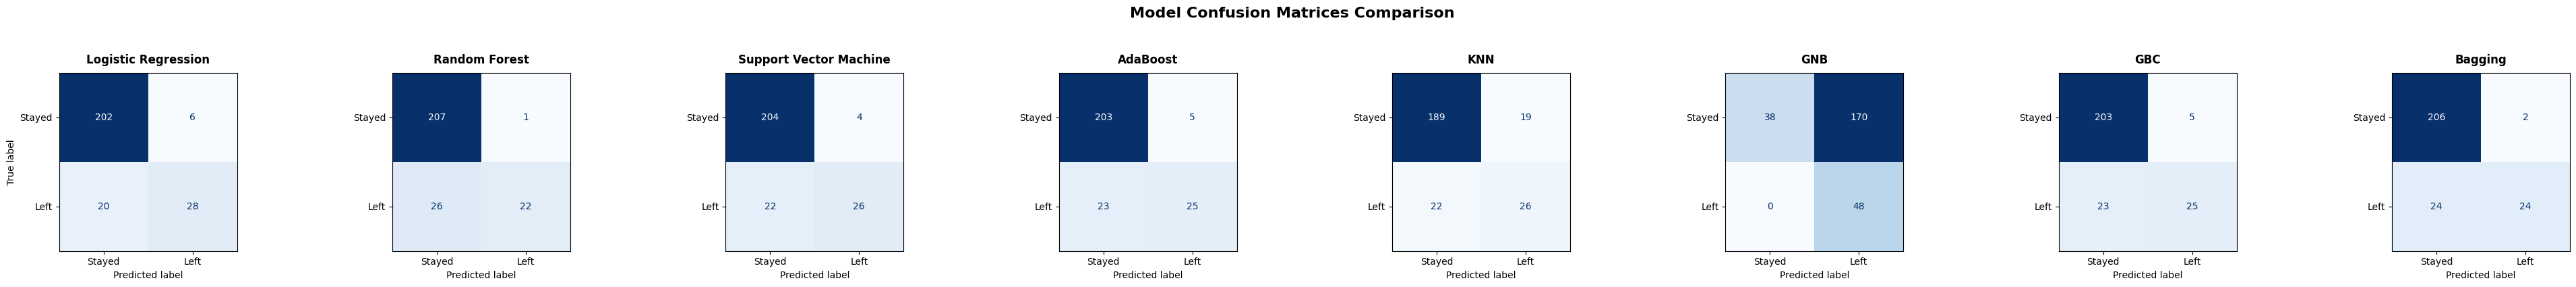

In [42]:
# Initialize subplots dynamically based on the number of models
num_models = len(models)
fig, axes = plt.subplots(1, num_models, figsize=(5 * num_models, 4))

# Handle edge case where there is only 1 model (axes wouldn't be an array)
if num_models == 1:
    axes = [axes]

# 2. Train and evaluate in a loop, plotting each matrix onto its designated subplot axis
for idx, (model_name, model_object) in enumerate(models.items()):
    
    # Recreate and fit your full pipeline
    full_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_object)
    ])
    full_pipeline.fit(X_train, y_train)
    
    # Generate predictions
    y_pred = full_pipeline.predict(X_test)
    
    # Compute the raw confusion matrix metrics
    cm = confusion_matrix(y_test, y_pred)
    
    # Render the confusion matrix visual directly onto the current subplot grid space
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, 
        display_labels=['Stayed', 'Left']
    )
    
    # Plot using a clean, accessible color map (e.g., 'Blues' or 'viridis')
    disp.plot(
        ax=axes[idx], 
        cmap='Blues', 
        colorbar=False,       # Turn off individual sidebars to keep layout neat
        values_format='d'     # Forces integer formatting instead of scientific notation
    )
    
    # Style the individual subplot title
    axes[idx].set_title(f"{model_name}", fontsize=12, fontweight='bold', pad=10)
    
    # Clean up inner labels so they don't look cluttered when side-by-side
    if idx > 0:
        axes[idx].set_ylabel('')

# 3. Final global layout polish
plt.suptitle('Model Confusion Matrices Comparison', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [45]:
X_train.columns

Index(['EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating', 'Gender', 'Age', 'BusinessTravel', 'Department',
       'DistanceFromHome (KM)', 'State', 'Ethnicity', 'Education',
       'EducationField', 'JobRole', 'MaritalStatus', 'Salary',
       'StockOptionLevel', 'OverTime', 'YearsAtCompany',
       'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')